Deep Convolutional Neural Network (CNN)
Multi-Class Image Classification
Purpose
Recognize handwritten digits and uppercase English letters.

Classes:
0-9
A-Z

Total Classes:
36
Framework
TensorFlow
Keras
Input Shape
28 × 28 × 1

Grayscale Image
Output Shape
36 Neurons

0-9
A-Z
Architecture
Input Layer
(28x28x1)

↓

Conv2D
32 Filters
3x3 Kernel
ReLU

↓

Batch Normalization

↓

MaxPooling2D

↓

Conv2D
64 Filters
3x3 Kernel
ReLU

↓

Batch Normalization

↓

MaxPooling2D

↓

Conv2D
128 Filters
3x3 Kernel
ReLU

↓

Batch Normalization

↓

MaxPooling2D

↓

Flatten

↓

Dense
256 Units
ReLU

↓

Dropout
0.4

↓

Dense
128 Units
ReLU

↓

Dropout
0.3

↓

Dense
36 Units
Softmax
Training Configuration
Optimizer:
Adam

Loss Function:
Sparse Categorical Crossentropy

Batch Size:
128

Epochs:
20-25

Callbacks:
EarlyStopping
ReduceLROnPlateau
ModelCheckpoint
Dataset

Use:

EMNIST

Digits: 0-9
Uppercase Letters: A-Z

Total Classes: 36

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', '1686215.pdf', 'Telangana Vidyadhan Entrance Test 2020 Instructions for the Test.pdf', 'IMG-20210724-WA0180 (1).jpg', 'IMG-20210724-WA0031 (1).jpg', 'IMG-20210724-WA0180.jpg', 'IMG-20210724-WA0031.jpg', 'IMG-20210724-WA0190.jpg', 'IMG-20210724-WA0189.jpg', 'IMG-20210724-WA0188.jpg', 'IMG-20210724-WA0187.jpg', 'IMG-20210724-WA0186.jpg', 'IMG-20210724-WA0185.jpg', 'IMG-20210724-WA0184.jpg', 'IMG-20210724-WA0183.jpg', 'IMG-20210724-WA0182.jpg', 'IMG-20210724-WA0181.jpg', 'IMG-20210724-WA0177.jpg', 'IMG-20210724-WA0176.jpg', 'IMG-20210724-WA0175.jpg', 'IMG-20210724-WA0174.jpg', 'IMG-20210724-WA0173.jpg', 'IMG-20210724-WA0171.jpg', 'IMG-20210724-WA0170.jpg', 'IMG-20210724-WA0169.jpg', 'IMG-20210724-WA0168.jpg', 'IMG-20210724-WA0167.jpg', 'IMG-20210724-WA0166.jpg', 'IMG-20210724-WA0165.jpg', 'IMG-20210724-WA0164.jpg', 'IMG-20210724-WA0163.jpg', 'IMG-20210724-WA0162.jpg', 'IMG-20210724-WA0161.jpg', 'IMG-20210724-WA0160.jpg', 'IMG-20210724-WA0159.jpg', 'IMG-20210724-WA0158.

In [3]:
import os

base_path = "/content/drive/MyDrive/code_alpha_handwritten"

folders = [
    "dataset",
    "models",
    "outputs",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [3]:
import os

print(os.listdir('/content/drive/MyDrive/code_alpha_handwritten'))

['dataset', 'models', 'outputs', 'notebooks']


In [4]:
!pip install emnist -q

In [5]:
!nvidia-smi

Tue Jun 16 06:49:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

install dataset

In [6]:
!pip install torch torchvision torchaudio -q
!pip install tqdm -q

In [7]:
from torchvision.datasets import EMNIST

train_dataset = EMNIST(
    root="./data",
    split="byclass",
    train=True,
    download=True
)

100%|██████████| 562M/562M [00:05<00:00, 102MB/s]


In [8]:
from torchvision.datasets import EMNIST
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = EMNIST(
    root="/content/data",
    split="byclass",
    train=True,
    download=True,
    transform=transform
)

test_dataset = EMNIST(
    root="/content/data",
    split="byclass",
    train=False,
    download=True,
    transform=transform
)

print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

Train: 697932
Test : 116323


In [9]:
import os

os.listdir("/content/data")

['EMNIST']

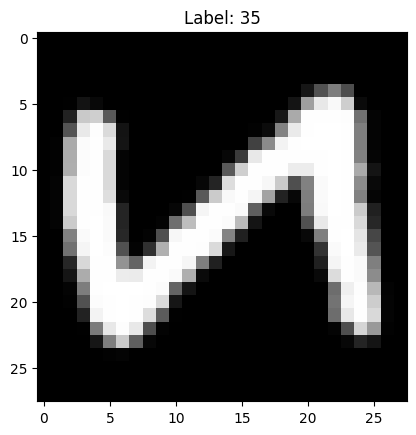

In [10]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

Inspect Dataset

Label: 35


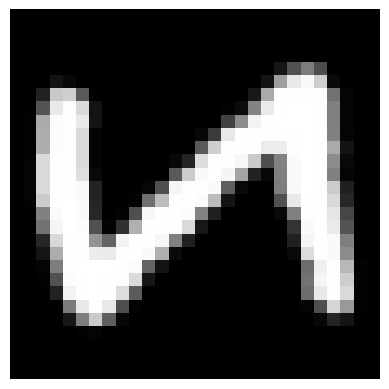

In [11]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

print("Label:", label)

plt.imshow(image.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

Create DataLoaders

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders Ready")

DataLoaders Ready


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

create the model CNN

In [15]:
class CharacterCNN(nn.Module):
    def __init__(self):
        super(CharacterCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 62)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
model = CharacterCNN()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(model)

CharacterCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
    (3): Dro

Move Model to GPU

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CharacterCNN().to(device)

print(device)

cuda


Define Loss Function

In [18]:
criterion = nn.CrossEntropyLoss()

Define Optimizer

In [19]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [20]:
EPOCHS = 30

best_acc = 0

train_losses = []
val_accuracies = []

In [21]:
from tqdm import tqdm
import torch

for epoch in range(EPOCHS):

    # TRAINING
    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    val_accuracies.append(accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

    # SAVE BEST MODEL
    if accuracy > best_acc:

        best_acc = accuracy

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/code_alpha_handwritten/models/best_character_model.pth"
        )

        print(f"Best Model Saved: {best_acc:.2f}%")

100%|██████████| 2727/2727 [01:26<00:00, 31.35it/s]


Epoch [1/30] | Loss: 0.6084 | Accuracy: 85.08%
Best Model Saved: 85.08%


100%|██████████| 2727/2727 [01:31<00:00, 29.83it/s]


Epoch [2/30] | Loss: 0.4439 | Accuracy: 86.10%
Best Model Saved: 86.10%


100%|██████████| 2727/2727 [01:39<00:00, 27.52it/s]


...

Epoch [28/30] | Loss: 0.3130 | Accuracy: 87.41%


100%|██████████| 2727/2727 [01:36<00:00, 28.30it/s]


Epoch [29/30] | Loss: 0.3119 | Accuracy: 87.46%


100%|██████████| 2727/2727 [01:39<00:00, 27.34it/s]


Epoch [30/30] | Loss: 0.3100 | Accuracy: 87.46%


In [24]:
model = CharacterCNN().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/code_alpha_handwritten/models/best_character_model.pth"
    )
)

model.eval()

print("Best Model Loaded")

Best Model Loaded


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy : 0.8754
Precision: 0.8669
Recall   : 0.8754
F1 Score : 0.8602


In [26]:
model.eval()

count = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        preds = preds.cpu().numpy()
        labels = labels.numpy()

        for i in range(len(preds)):

            print(
                f"Image {count+1} | "
                f"Actual: {labels[i]} | "
                f"Predicted: {preds[i]}"
            )

            count += 1

            if count == 100:
                break

        if count == 100:
            break

Image 1 | Actual: 18 | Predicted: 1
Image 2 | Actual: 36 | Predicted: 36
Image 3 | Actual: 0 | Predicted: 0
Image 4 | Actual: 3 | Predicted: 3
Image 5 | Actual: 33 | Predicted: 59
Image 6 | Actual: 30 | Predicted: 30
Image 7 | Actual: 24 | Predicted: 24
Image 8 | Actual: 40 | Predicted: 40
Image 9 | Actual: 5 | Predicted: 5
Image 10 | Actual: 8 | Predicted: 8
Image 11 | Actual: 2 | Predicted: 2
Image 12 | Actual: 4 | Predicted: 4
Image 13 | Actual: 2 | Predicted: 2
Image 14 | Actual: 47 | Predicted: 1
Image 15 | Actual: 2 | Predicted: 2
Image 16 | Actual: 3 | Predicted: 3
Image 17 | Actual: 7 | Predicted: 7
Image 18 | Actual: 32 | Predicted: 32
Image 19 | Actual: 7 | Predicted: 7
Image 20 | Actual: 5 | Predicted: 5
Image 21 | Actual: 3 | Predicted: 3
Image 22 | Actual: 60 | Predicted: 60
Image 23 | Actual: 18 | Predicted: 1
Image 24 | Actual: 46 | Predicted: 46
Image 25 | Actual: 18 | Predicted: 18
Image 26 | Actual: 36 | Predicted: 36
Image 27 | Actual: 59 | Predicted: 33
Image 28 | A

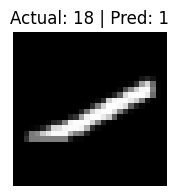

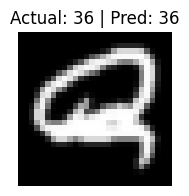

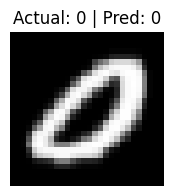

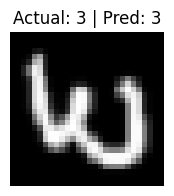

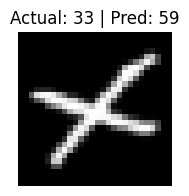

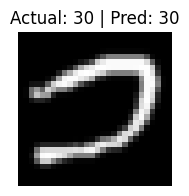

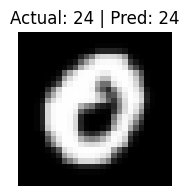

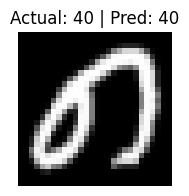

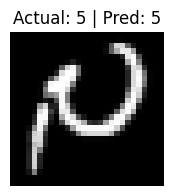

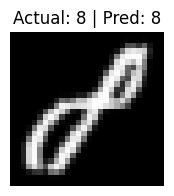

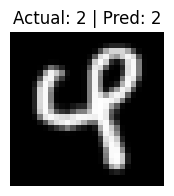

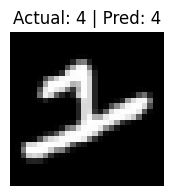

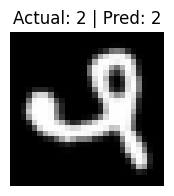

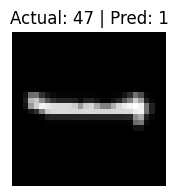

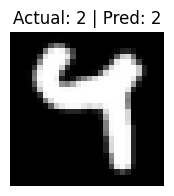

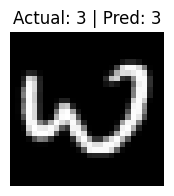

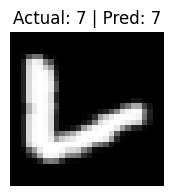

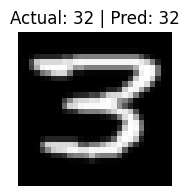

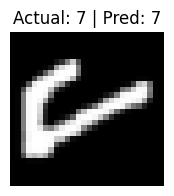

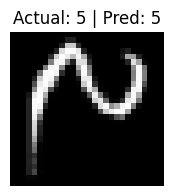

In [27]:
import matplotlib.pyplot as plt

model.eval()

count = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images.to(device))

        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):

            plt.figure(figsize=(2,2))
            plt.imshow(
                images[i].squeeze(),
                cmap="gray"
            )

            plt.title(
                f"Actual: {labels[i]} | Pred: {preds[i].item()}"
            )

            plt.axis("off")
            plt.show()

            count += 1

            if count == 20:
                break

        if count == 20:
            break

In [28]:
results = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images.to(device))

        _, preds = torch.max(outputs, 1)

        preds = preds.cpu().numpy()

        for actual, pred in zip(labels.numpy(), preds):

            results.append([actual, pred])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Actual", "Predicted"]
)

print(results_df.head(50))

    Actual  Predicted
0       18          1
1       36         36
2        0          0
3        3          3
4       33         59
5       30         30
6       24         24
7       40         40
8        5          5
9        8          8
10       2          2
11       4          4
12       2          2
13      47          1
14       2          2
15       3          3
16       7          7
17      32         32
18       7          7
19       5          5
20       3          3
21      60         60
22      18          1
23      46         46
24      18         18
25      36         36
26      59         33
27      12         12
28      37         37
29       7          7
30      53         53
31       7          7
32      15         15
33       1          1
34       9          9
35      38         12
36      43         43
37      44         44
38       8          8
39       5          5
40      40         40
41       7          7
42      43         43
43      19         19
44       7

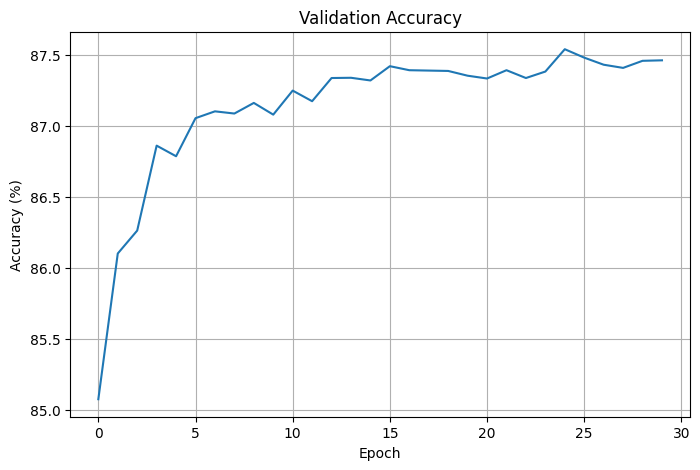

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(val_accuracies)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/code_alpha_handwritten/outputs/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

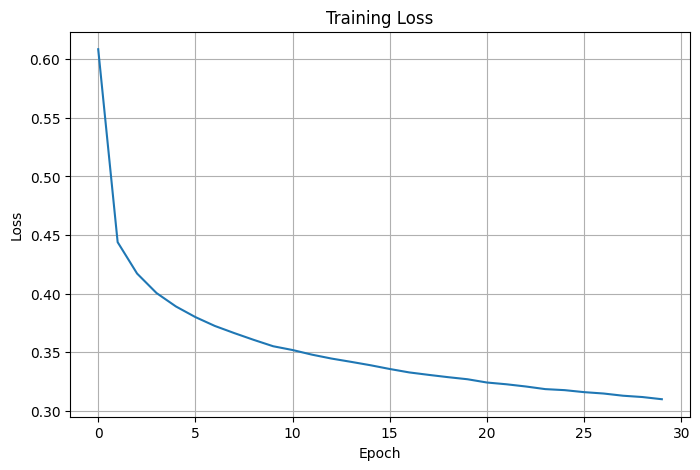

In [30]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/code_alpha_handwritten/outputs/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

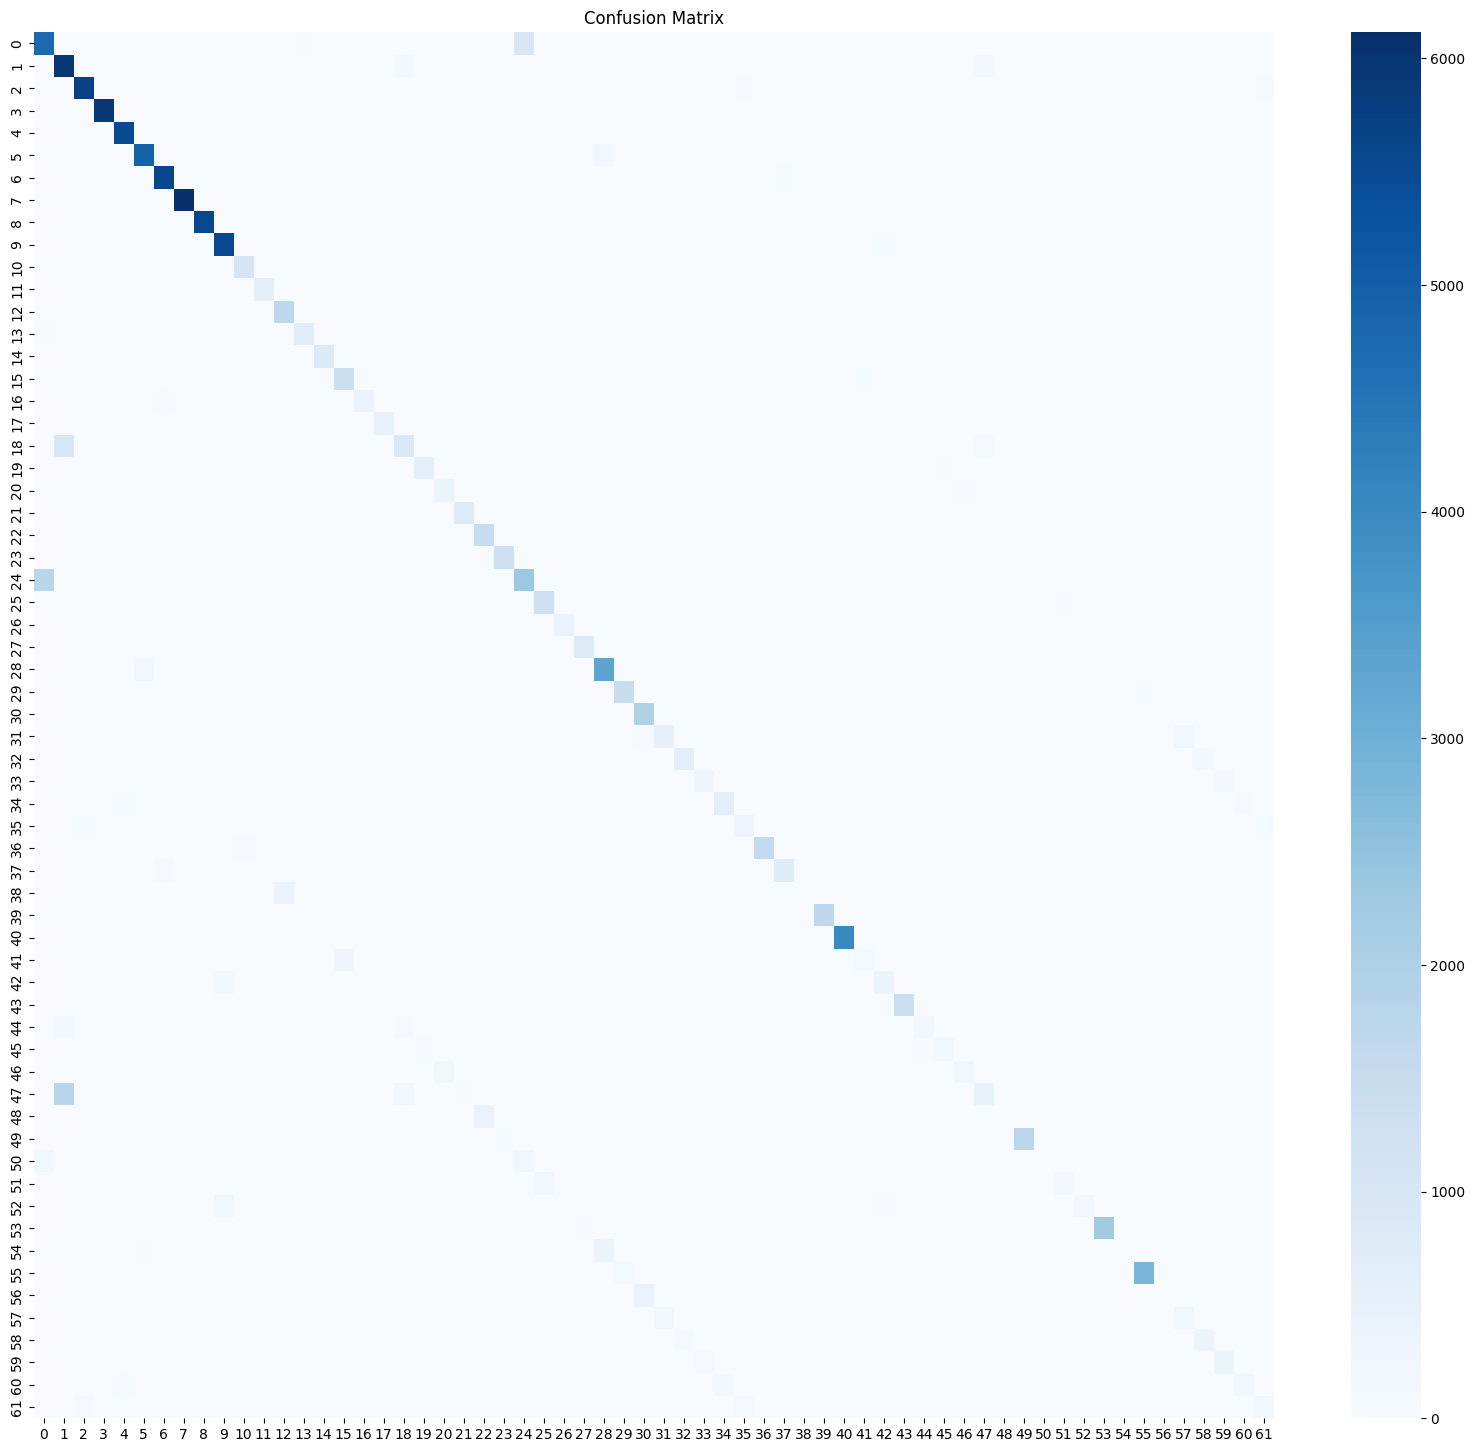

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(20,18))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/code_alpha_handwritten/outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df.to_csv(
    "/content/drive/MyDrive/code_alpha_handwritten/outputs/model_metrics.csv",
    index=False
)

In [34]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           0       0.70      0.83      0.76      5778
           1       0.67      0.95      0.78      6330
           2       0.97      0.98      0.97      5869
           3       0.99      1.00      0.99      5969
           4       0.97      0.98      0.97      5619
           5       0.95      0.95      0.95      5190
           6       0.98      0.98      0.98      5705
           7       0.99      1.00      0.99      6139
           8       0.98      0.99      0.99      5633
           9       0.93      0.98      0.96      5686
          10       0.95      0.98      0.97      1062
          11       0.94      0.96      0.95       648
          12       0.77      0.98      0.86      1739
          13       0.92      0.92      0.92       779
          14       0.95      0.99      0.97       851
          15       0.81      0.93      0.87      1440
          16       0.95      0.90      0.92       447
          17       0.93    

In [35]:
precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

In [36]:
import numpy as np

print("Actual Classes    :", len(np.unique(all_labels)))
print("Predicted Classes :", len(np.unique(all_preds)))

print(np.unique(all_preds))

Actual Classes    : 62
Predicted Classes : 61
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61]


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.875407271132966
Precision: 0.866946758647051
Recall   : 0.875407271132966
F1 Score : 0.8601736629594703
